In [ ]:
from copy import deepcopy

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tqdm
from skimage.exposure import rescale_intensity
from skimage.measure import label, regionprops
from skimage.morphology import binary_dilation
from skimage.util import montage

sns.set_theme(
    style="ticks",
    font_scale=1.5,
    rc={
        "legend.fancybox": False,
        "legend.shadow": False,
        "legend.frameon": True,
    },
)


In [ ]:
df = pd.read_csv(".//nuc_intensity.csv")
conditions = {
    "A1": "12h_mC2+A100➔48h_B50➔48h_B50(ctrl-1)",
    "A2": "12h_mC2+A100➔48h_B50➔48h_A50+LDN",
    "A3": "12h_mC2+A100➔48h_B50➔48h_A50+LDN+IWP2",
    "A4": "12h_mC2+A100➔36h_B50➔60h_C3",
    "A5": "12h_mC2+A100➔36h_B50➔60h_A50_LDN",
    "A6": "12h_mC2+A100➔36h_B50➔60h_A50+LDN+IWP2",
    "B1": "12h_mC2+A100➔48h_B50➔48h_A50",
    "B2": "12h_mC2+A100➔48h_B50➔48h_A50+IWP2(5µM)",
    "B3": "12h_mC2+A100➔48h_B50➔48h_IWP2",
    "B4": "12h_mC2+A100➔36h_B50➔60h_A50",
    "B5": "12h_mC2+A100➔36h_B50➔60h_A50+IWP2(5µM)",
    "B6": "12h_mC2+A100➔36h_B50➔60h_IWP2(5µM)",
    "C1": "12h_mC2+A100➔48h_B50➔48h_LDN(1µM)",
    "C2": "12h_mC2+A100➔48h_B50➔48h_LDN(1µM)+IWP2(5µM)",
    "C3": "12h_mC2+A100➔48h_B50➔48h_B50(ctrl-2)",
    "C4": "12h_mC2+A100➔36h_B50➔60h_LDN(1µM)",
    "C5": "12h_mC2+A100➔36h_B50➔60h_LDN(1µM)+IWP2(5µM)",
    "C6": "12h_mC2+A100➔36h_B50➔60h_B50(ctrl-3)",
}
conditons_list = list(conditions.values())
wellId_list = list(conditions.keys())
df["well_id"] = df["cell_conditions"].copy()
df["cell_conditions"] = df["cell_conditions"].map(conditions)
img_data = {}
for i in tqdm(range(18)):
    colony_imgs = []
    colony_imgs_rescaled = []
    for j in range(4):
        dapi = plt.imread(f".//MIP//img_nuc//Image_{i * 4 + j + 1:03}_MIP_w0000.tif")
        eomes = plt.imread(f".//MIP//Image_{i * 4 + j + 1:03}_MIP_w0001.tif")
        tfap2c = plt.imread(f".//MIP//Image_{i * 4 + j + 1:03}_MIP_w0002.tif")
        sox17 = plt.imread(f".//MIP//Image_{i * 4 + j + 1:03}_MIP_w0003.tif")
        with h5py.File(
            f".//MIP//img_nuc//Image_{i * 4 + j + 1:03}_MIP_w0000_Simple Segmentation.h5",
            "r",
        ) as f:
            dat = np.array(f["exported_data"])
            colony_mask = binary_dilation(dat.squeeze() == 1, np.ones((20, 20)))
            colony_mask = label(colony_mask)
            colony_props = regionprops(colony_mask)
            # Sort by area and get top 7 largest components
            colony_props = sorted(colony_props, key=lambda x: x.area, reverse=True)[:7]
        for prop in colony_props:
            colony_imgs.append(
                np.stack(
                    [
                        dapi[prop.bbox[0] : prop.bbox[2], prop.bbox[1] : prop.bbox[3]],
                        eomes[prop.bbox[0] : prop.bbox[2], prop.bbox[1] : prop.bbox[3]],
                        tfap2c[
                            prop.bbox[0] : prop.bbox[2], prop.bbox[1] : prop.bbox[3]
                        ],
                        sox17[prop.bbox[0] : prop.bbox[2], prop.bbox[1] : prop.bbox[3]],
                    ],
                    2,
                )
            )
    img_data[wellId_list[i]] = {
        "colony_img": colony_imgs.copy(),
        "condition": conditons_list[i],
    }
img_data_original = deepcopy(img_data)

100%|██████████| 18/18 [01:36<00:00,  5.34s/it]


In [436]:
img_data = deepcopy(img_data_original)
dapi_in_range = (0, 15000)
eomes_in_range = (0, 1500 * 3)
tfap2c_in_range = (0, 2000 * 3)
sox17_in_range = (0, 2000 * 3)

for key, value in img_data.items():
    print(key)
    for i, img in enumerate(value["colony_img"]):
        img[:, :, 0] = rescale_intensity(img[:, :, 0], in_range=dapi_in_range)
        img[:, :, 1] = rescale_intensity(img[:, :, 1], in_range=eomes_in_range)
        img[:, :, 2] = rescale_intensity(img[:, :, 2], in_range=tfap2c_in_range)
        img[:, :, 3] = rescale_intensity(img[:, :, 3], in_range=sox17_in_range)

img_size = [0, 0]
for key, value in img_data.items():
    for i in range(28):
        xsize = value["colony_img"][i].shape[0]
        ysize = value["colony_img"][i].shape[1]
        if xsize > img_size[0]:
            img_size[0] = xsize
            print(f"{key}-{i}")
        if ysize > img_size[1]:
            img_size[1] = ysize
            print(f"{key}-{i}")
xysize = max(img_size)

for key, value in img_data.items():
    for i in range(28):
        xsize = value["colony_img"][i].shape[0]
        ysize = value["colony_img"][i].shape[1]
        xpad = (xysize - xsize) // 2
        ypad = (xysize - ysize) // 2
        value["colony_img"][i] = np.pad(
            value["colony_img"][i],
            ((xpad, xysize - xsize - xpad), (ypad, xysize - ysize - ypad), (0, 0)),
        )

A1
A2
A3
A4
A5
A6
B1
B2
B3
B4
B5
B6
C1
C2
C3
C4
C5
C6
A1-0
A1-0
A1-1
A1-3
A1-22
A2-0
A3-0
A4-0
B3-8
C5-0
C5-2
C5-7
C5-8
C5-15
C6-7


In [475]:
img_montage = {}
for key, value in img_data.items():
    img_montage[key] = montage(
        np.stack([im[:, :, 1:] / 65535 for im in value["colony_img"]]),
        channel_axis=3,
        padding_width=10,
        fill=[1, 1, 1],
        grid_shape=(4, 7),
    )

In [489]:
img_montage_dapi = {}
for key, value in img_data.items():
    img_montage_dapi[key] = montage(
        np.stack([im[:, :, 0] / 65535 for im in value["colony_img"]]),
        padding_width=10,
        fill=[1, 1, 1],
        grid_shape=(4, 7),
    )

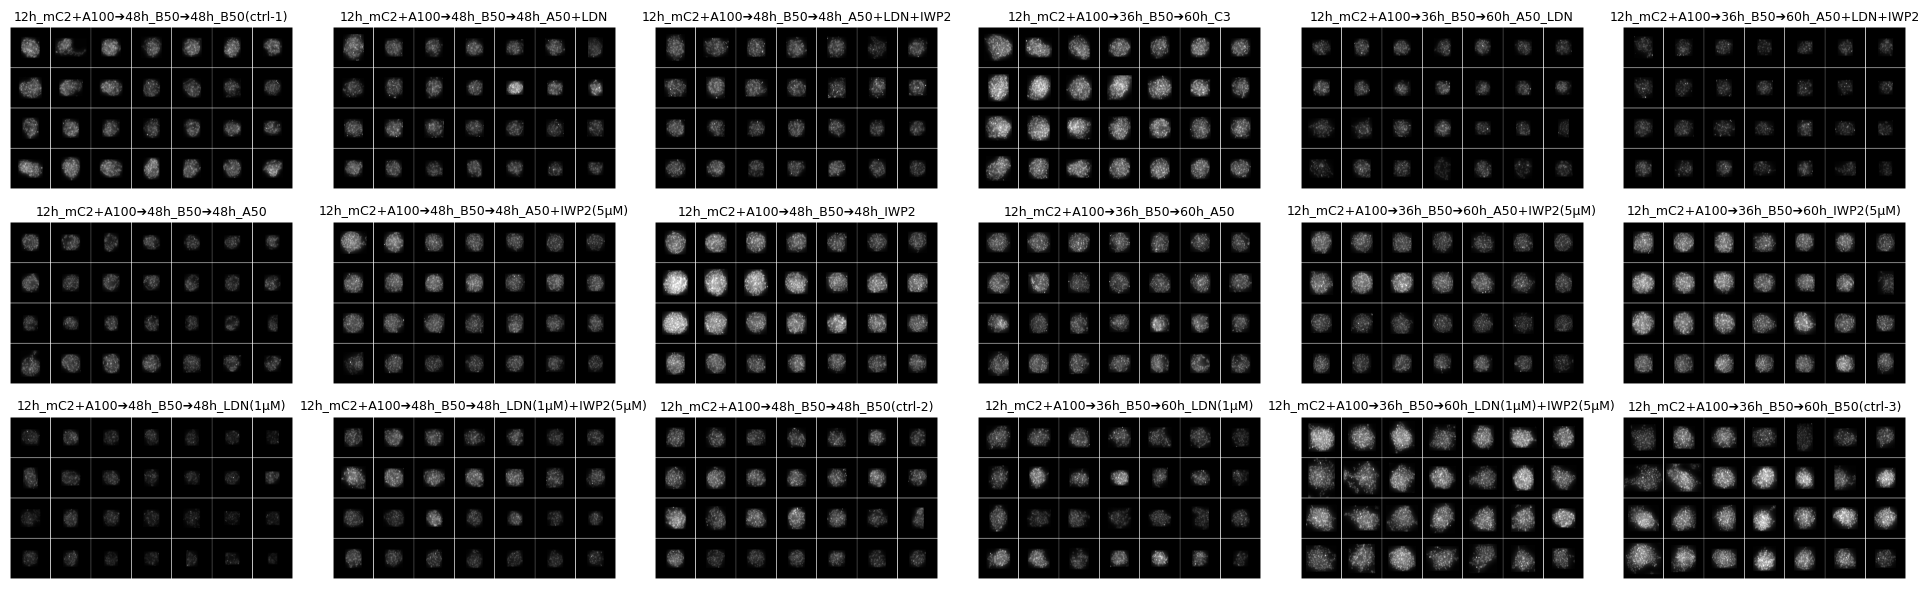

In [493]:
fig, axes = plt.subplots(3, 6, figsize=(20, 6))
for i, (key, value) in enumerate(img_montage_dapi.items()):
    ax = axes.flat[i]
    ax.imshow(value, cmap="gray")
    ax.axis("off")
    ax.set_title(img_data[key]["condition"], fontsize=9)
fig.set_tight_layout(True)
plt.savefig("montage_dapi.png", dpi=600, bbox_inches="tight")

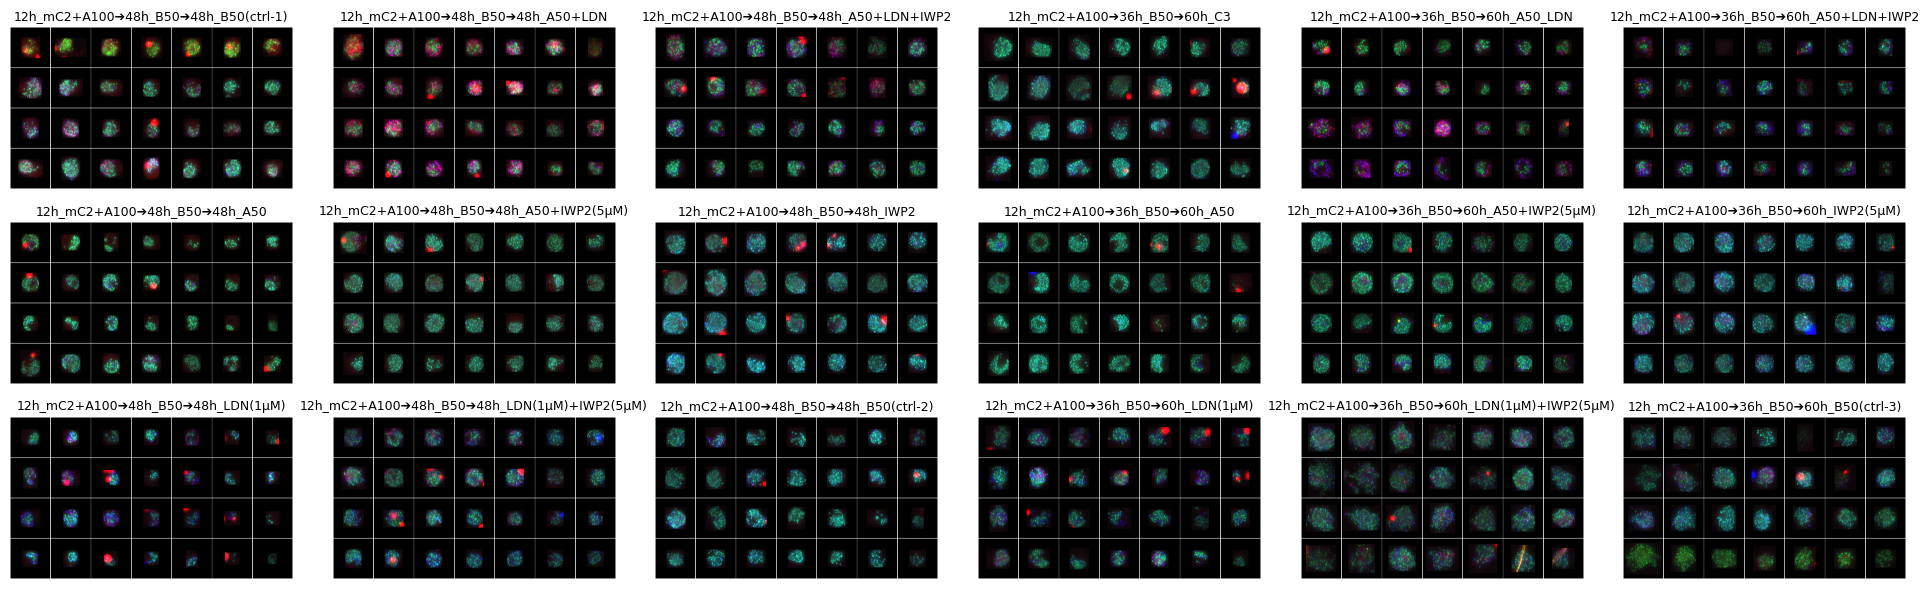

In [492]:
fig, axes = plt.subplots(3, 6, figsize=(20, 6))
for i, (key, value) in enumerate(img_montage.items()):
    ax = axes.flat[i]
    ax.imshow(value)
    ax.axis("off")
    ax.set_title(img_data[key]["condition"], fontsize=9)
fig.set_tight_layout(True)
plt.savefig("montage.png", dpi=600, bbox_inches="tight")

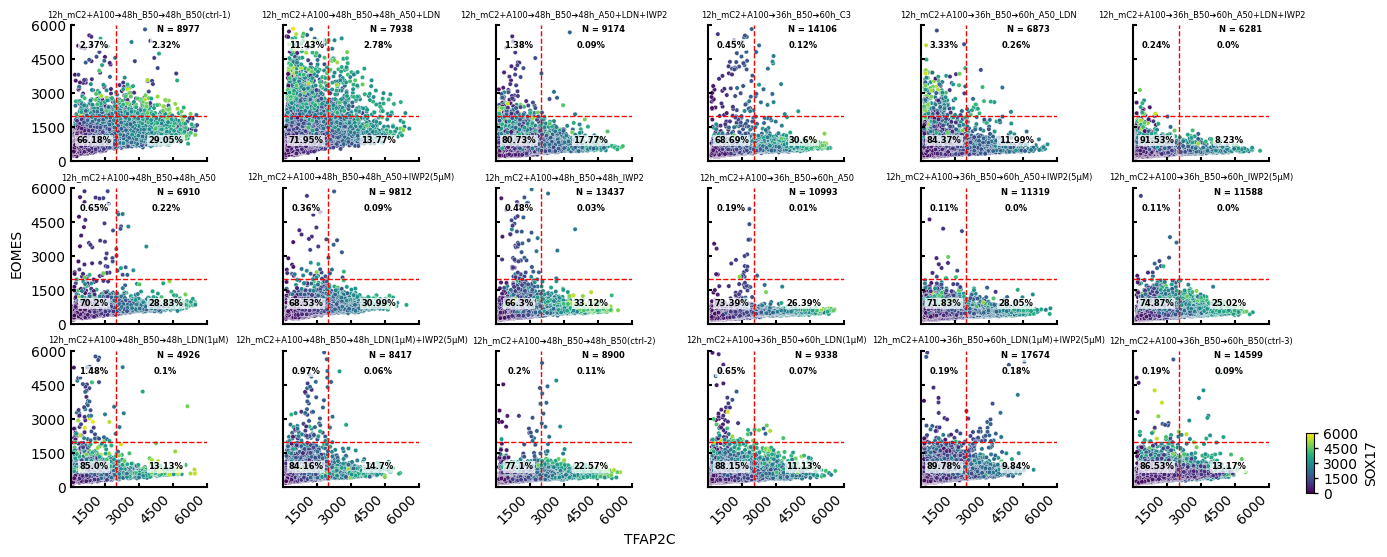

In [ ]:
plt.rcdefaults()
plt.style.use("default")
fig, axes = plt.subplots(3, 6, figsize=(16, 6))
n_ticks = 5
hue_norm = (
    0,
    (df["nuc_sox17"].max() // 100 + 1) * 100,
)
eomes_lim = (0, (df["nuc_eomes"].max() // 100 + 1) * 100)
tfap2c_lim = (0, (df["nuc_tfap2c"].max() // 100 + 3) * 100)
eomes_thresh = 2000
tfap2c_thresh = 2000

for i, well in enumerate(wellId_list):
    ax = axes.flat[i]
    df_sub = df[df["well_id"] == well]
    total_points = len(df_sub)
    qua1_percent = np.round(
        np.logical_and(
            df_sub["nuc_eomes"] > eomes_thresh, df_sub["nuc_tfap2c"] > tfap2c_thresh
        ).sum()
        / len(df_sub)
        * 100,
        2,
    )
    qua2_percent = np.round(
        np.logical_and(
            df_sub["nuc_eomes"] > eomes_thresh, df_sub["nuc_tfap2c"] < tfap2c_thresh
        ).sum()
        / len(df_sub)
        * 100,
        2,
    )
    qua3_percent = np.round(
        np.logical_and(
            df_sub["nuc_eomes"] < eomes_thresh, df_sub["nuc_tfap2c"] < tfap2c_thresh
        ).sum()
        / len(df_sub)
        * 100,
        2,
    )
    qua4_percent = np.round(
        np.logical_and(
            df_sub["nuc_eomes"] < eomes_thresh, df_sub["nuc_tfap2c"] > tfap2c_thresh
        ).sum()
        / len(df_sub)
        * 100,
        2,
    )

    sns.scatterplot(
        df_sub,
        x="nuc_tfap2c",
        y="nuc_eomes",
        hue="nuc_sox17",
        hue_norm=(hue_norm[0], hue_norm[1]),
        palette="viridis",
        ax=ax,
        legend=False,
        s=10,
    )

    # Add percentage annotations to each quadrant with white background
    for text_x, text_y, percentage in [
        (tfap2c_lim[1] * 0.7, eomes_lim[1] * 0.85, qua1_percent),
        (tfap2c_lim[1] * 0.17, eomes_lim[1] * 0.85, qua2_percent),
        (tfap2c_lim[1] * 0.17, eomes_lim[1] * 0.15, qua3_percent),
        (tfap2c_lim[1] * 0.7, eomes_lim[1] * 0.15, qua4_percent),
    ]:
        ax.text(
            text_x,
            text_y,
            f"{percentage}%",
            fontsize=6,
            fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1),
            ha="center",
            va="center",
        )

    # Add total number of points at top right corner
    ax.text(
        tfap2c_lim[1] * 0.95,
        eomes_lim[1] * 1,
        f"N = {total_points}",
        fontsize=6,
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1),
        ha="right",
        va="top",
    )

    ax.axvline(tfap2c_thresh, color="red", linestyle="--", linewidth=1)
    ax.axhline(eomes_thresh, color="red", linestyle="--", linewidth=1)
    ax.axis("square")
    sns.despine()
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks(
        np.linspace(tfap2c_lim[0], tfap2c_lim[1], n_ticks)[1:],
        labels=[
            int(val) for val in np.linspace(tfap2c_lim[0], tfap2c_lim[1], n_ticks)[1:]
        ],
        rotation=45,
        ha="right",
    )
    ax.set_yticks(np.linspace(eomes_lim[0], eomes_lim[1], n_ticks))

    ax.set_xlim(tfap2c_lim)
    ax.set_ylim(eomes_lim)
    ax.tick_params(direction="in", length=3, width=1.5, color="black")
    ax.set_title(img_data[well]["condition"], fontsize=6)
    if i < 12:
        ax.set_xticklabels([])
    if i % 6 != 0:
        ax.set_yticklabels([])

fig.supxlabel("TFAP2C", fontsize=10, y=0.01)
fig.supylabel("EOMES", fontsize=10, x=0.1)

norm = plt.Normalize(hue_norm[0], hue_norm[1])
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
h = fig.colorbar(sm, cax=fig.add_axes([0.91, 0.1, 0.005, 0.1]))
h.set_label("SOX17")
h.set_ticks(np.linspace(hue_norm[0], hue_norm[1], n_ticks))
h.ax.tick_params(width=1, length=3)
plt.savefig("olympus_20x_quantification.png", dpi=600, bbox_inches="tight")
plt.show()
